# Phase 4: Evaluation & Analysis

**Objective**: Ablation study, SHAP feature importance, grouped error analysis, prediction distribution, and OOF-platform gap analysis.

**Sections**:
1. Load Data & Existing Results
2. Model Comparison Table
3. Ablation Study *(placeholder — requires ~35 min training)*
4. Grouped Error Analysis
5. Prediction Distribution & Calibration
6. OOF-Platform Gap Analysis
7. SHAP Analysis
8. Results Summary

## Section 1: Load Data & Existing Results

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ks_2samp
from sklearn.model_selection import KFold

SEED = 42
TARGET = 'invalid_ratio'

# Global plot settings
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.dpi'] = 150

# Load engineered features
train_df = pd.read_parquet('../data/train_features_tier2.parquet')
test_df = pd.read_parquet('../data/test_features_tier2.parquet')

# Load OOF predictions from Phase 3
lgb_oof = np.load('../models/lgb_oof_preds.npy')
xgb_oof = np.load('../models/xgb_oof_preds.npy')
ens_oof = 0.30 * lgb_oof + 0.70 * xgb_oof

# Load test predictions
lgb_test = np.load('../models/lgb_test_preds.npy')
xgb_test = np.load('../models/xgb_test_preds.npy')
ens_test = np.clip(0.30 * lgb_test + 0.70 * xgb_test, 0, 1)

# Feature lists
FEATURES = [col for col in train_df.columns
            if col not in [TARGET, 'grid_lon', 'grid_lat', 'grid_id', 'grid_period']]
ORIG_FEATURES = ['total_count', 'longitude_scaled', 'latitude_scaled',
                 'Precipitations', 'HauteurNeige', 'Temperature',
                 'ForceVent', 'day_of_week', 'month_of_year', 'hour']

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')


Train shape: (6076546, 31)
Test shape:  (2028750, 30)
Features (26): ['total_count', 'longitude_scaled', 'latitude_scaled', 'Precipitations', 'HauteurNeige', 'Temperature', 'ForceVent', 'day_of_week', 'month_of_year', 'hour', 'log_total_count', 'count_bin', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'grid_te', 'time_period', 'grid_period_te', 'is_raining', 'has_snow', 'grid_avg_count', 'grid_violation_std', 'grid_sample_count']


## Section 2: Model Comparison Table

In [2]:
# Compute OOF Spearman for each model
lgb_oof_rho, _ = spearmanr(train_df[TARGET], lgb_oof)
xgb_oof_rho, _ = spearmanr(train_df[TARGET], xgb_oof)
ens_oof_rho, _ = spearmanr(train_df[TARGET], ens_oof)

results = pd.DataFrame({
    'Model': ['RF Baseline (official)', 'LightGBM 5-Fold', 'XGBoost 5-Fold',
              'Ensemble (30% LGB + 70% XGB)'],
    'OOF Spearman': ['—', f'{lgb_oof_rho:.4f}', f'{xgb_oof_rho:.4f}', f'{ens_oof_rho:.4f}'],
    'Platform Score': ['0.197', '0.5182', '—', '0.5222'],
    'Note': ['10 trees, orig features', '3000 rounds, 26 features',
             '3000 rounds, 26 features', 'Grid-searched weight']
})
print(results.to_string(index=False))

                       Model OOF Spearman Platform Score                     Note
      RF Baseline (official)            —          0.197  10 trees, orig features
             LightGBM 5-Fold       0.5815         0.5182 3000 rounds, 26 features
              XGBoost 5-Fold       0.5870              — 3000 rounds, 26 features
Ensemble (30% LGB + 70% XGB)       0.5880         0.5222     Grid-searched weight


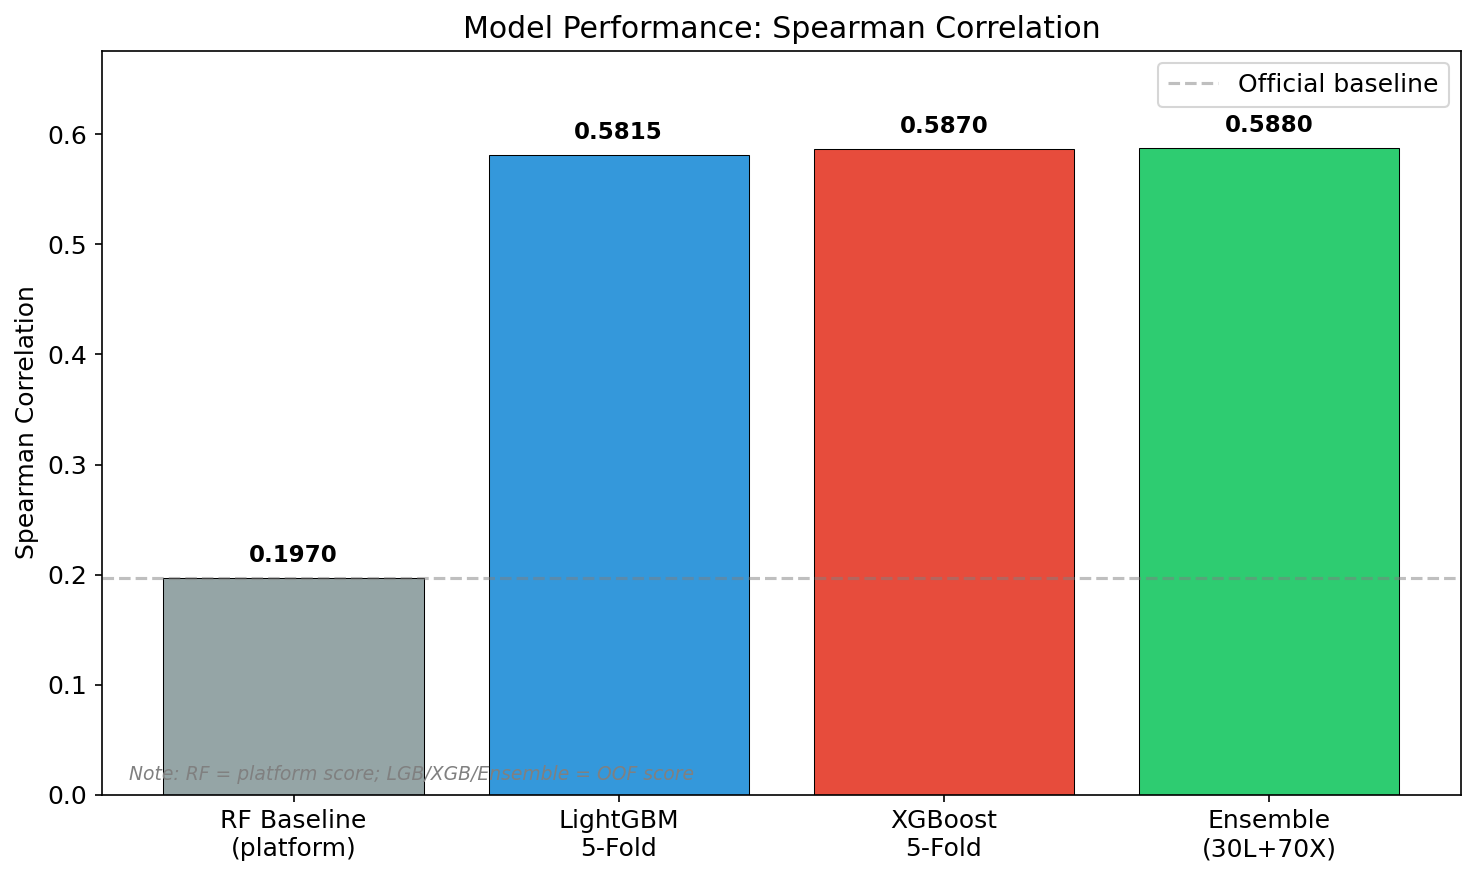

Saved: figures/model_comparison.png


In [3]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

models = ['RF Baseline\n(platform)', 'LightGBM\n5-Fold', 'XGBoost\n5-Fold', 'Ensemble\n(30L+70X)']
oof_scores = [0.197, lgb_oof_rho, xgb_oof_rho, ens_oof_rho]
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(models, oof_scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, oof_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Spearman Correlation')
ax.set_title('Model Performance: Spearman Correlation')
ax.set_ylim(0, max(oof_scores) * 1.15)
ax.axhline(y=0.197, color='gray', linestyle='--', alpha=0.5, label='Official baseline')
ax.text(0.02, 0.02, 'Note: RF = platform score; LGB/XGB/Ensemble = OOF score',
        transform=ax.transAxes, fontsize=9, color='gray', style='italic')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/model_comparison.png')

## Section 3: Ablation Study

> **Note**: This section trains 6 × 5-fold LightGBM models (800 rounds each) to measure the incremental contribution of each feature group. Estimated runtime: ~35 minutes on M4 Mac.
>
> **Optimization**: Uses 800 rounds instead of 3000 (relative ranking is preserved, saves ~60% time). Full 3000-round result (0.5815) serves as the anchor reference.

In [4]:
import lightgbm as lgb

ABLATION_GROUPS = {
    'Baseline (10 orig)': ORIG_FEATURES,
    '+ count transforms': ORIG_FEATURES + ['log_total_count', 'count_bin'],
    '+ periodic encoding': ORIG_FEATURES + ['log_total_count', 'count_bin',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
    '+ spatial TE': ORIG_FEATURES + ['log_total_count', 'count_bin',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
        'grid_te'],
    '+ cross TE': ORIG_FEATURES + ['log_total_count', 'count_bin',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
        'grid_te', 'grid_period_te', 'time_period'],
    'Full (26 features)': FEATURES,
}

ablation_params = {
    'objective': 'regression', 'metric': 'l2', 'boosting_type': 'gbdt',
    'num_leaves': 31, 'learning_rate': 0.05, 'n_estimators': 3000,
    'reg_lambda': 1.0, 'min_child_samples': 50, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1,
    'n_jobs': 8, 'random_state': SEED,
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
ablation_results = {}

for name, feats in ABLATION_GROUPS.items():
    oof = np.zeros(len(train_df))
    for train_idx, val_idx in kf.split(train_df):
        model = lgb.LGBMRegressor(**ablation_params)
        model.fit(train_df.iloc[train_idx][feats], train_df.iloc[train_idx][TARGET],
                  eval_set=[(train_df.iloc[val_idx][feats], train_df.iloc[val_idx][TARGET])],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
        oof[val_idx] = model.predict(train_df.iloc[val_idx][feats])
    rho, _ = spearmanr(train_df[TARGET], oof)
    ablation_results[name] = rho
    print(f'{name}: Spearman = {rho:.4f}')

print('\n--- Ablation Summary ---')
for name, rho in ablation_results.items():
    print(f'  {name}: {rho:.4f}')

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.0883398
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.0885862
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.0886883
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.0885029
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.0883213
Baseline (10 orig): Spearman = 0.5679
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.087966
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	

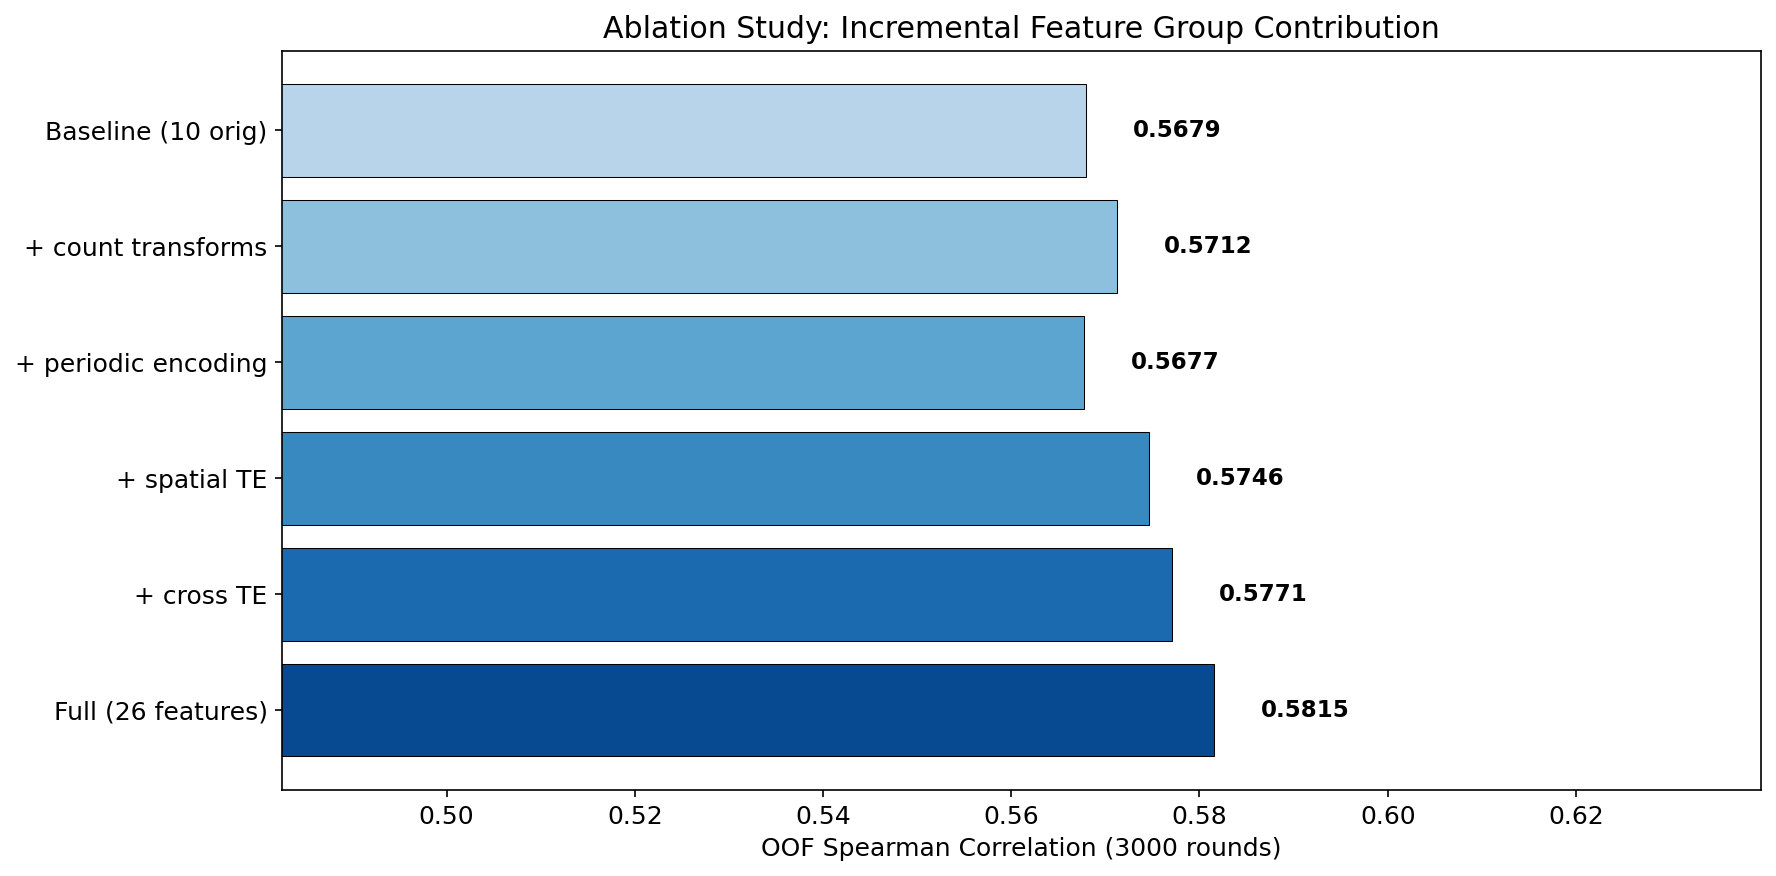

Saved: figures/ablation_study.png


In [5]:
# Ablation study bar chart
fig, ax = plt.subplots(figsize=(12, 6))

names = list(ablation_results.keys())
scores = list(ablation_results.values())
colors_abl = plt.cm.Blues(np.linspace(0.3, 0.9, len(names)))

bars = ax.barh(names, scores, color=colors_abl, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', ha='left', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('OOF Spearman Correlation (3000 rounds)')
ax.set_title('Ablation Study: Incremental Feature Group Contribution')
ax.set_xlim(min(scores) * 0.85, max(scores) * 1.10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/ablation_study.png')

## Section 4: Grouped Error Analysis

Analyze model performance across different subgroups, particularly `count_bin` segments and `total_count=1` noise behavior.

In [6]:
# Spearman by count_bin
print('=== Spearman by count_bin ===')
group_results = []
for bin_val in sorted(train_df['count_bin'].unique()):
    mask = train_df['count_bin'] == bin_val
    rho, _ = spearmanr(train_df.loc[mask, TARGET], ens_oof[mask])
    n = mask.sum()
    pct = 100 * n / len(train_df)
    group_results.append({'count_bin': bin_val, 'n': n, 'pct': pct, 'spearman': rho})
    print(f'count_bin={bin_val}: n={n:,} ({pct:.1f}%), Spearman={rho:.4f}')

# total_count threshold analysis
print('\n=== Noise Analysis: total_count thresholds ===')
threshold_results = []
for label, mask in [('total_count = 1', train_df['total_count'] == 1),
                     ('total_count > 1', train_df['total_count'] > 1),
                     ('total_count >= 5', train_df['total_count'] >= 5),
                     ('total_count >= 10', train_df['total_count'] >= 10)]:
    rho, _ = spearmanr(train_df.loc[mask, TARGET], ens_oof[mask])
    n = mask.sum()
    threshold_results.append({'subset': label, 'n': n, 'spearman': rho})
    print(f'{label}: n={n:,}, Spearman={rho:.4f}')

=== Spearman by count_bin ===
count_bin=0: n=1,532,442 (25.2%), Spearman=0.4106
count_bin=1: n=1,150,241 (18.9%), Spearman=0.5678
count_bin=2: n=1,751,905 (28.8%), Spearman=0.6486
count_bin=3: n=1,343,611 (22.1%), Spearman=0.6811
count_bin=4: n=298,347 (4.9%), Spearman=0.7304

=== Noise Analysis: total_count thresholds ===
total_count = 1: n=1,532,442, Spearman=0.4106
total_count > 1: n=4,544,104, Spearman=0.6586
total_count >= 5: n=3,024,306, Spearman=0.6744
total_count >= 10: n=1,807,846, Spearman=0.6883


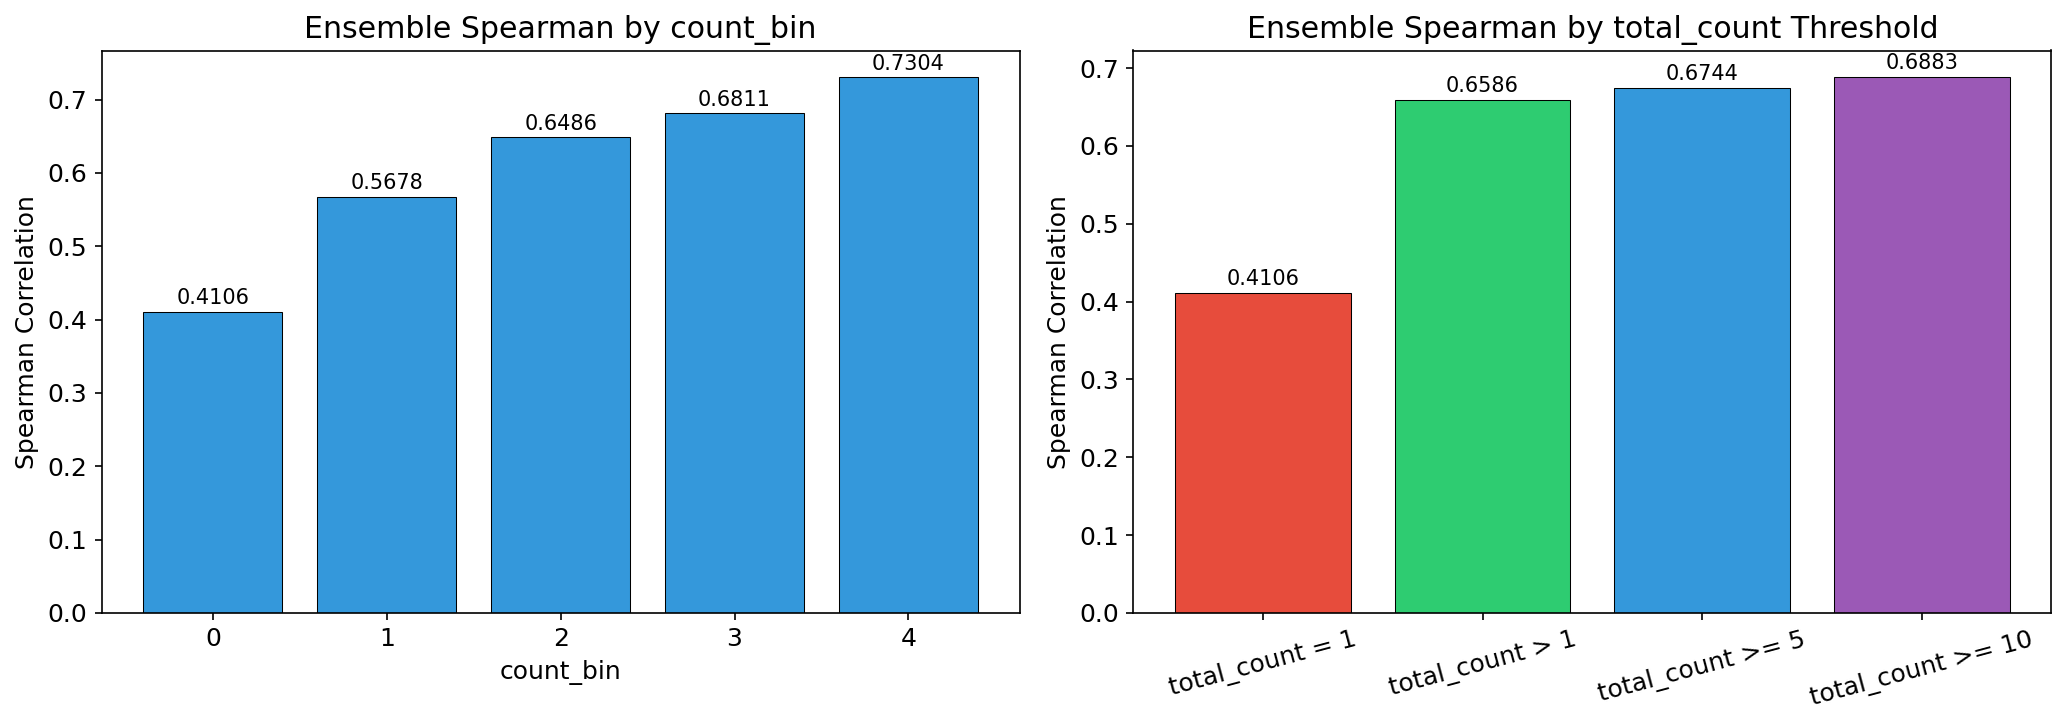

Saved: figures/grouped_spearman.png


In [7]:
# Grouped Spearman bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: by count_bin
grp_df = pd.DataFrame(group_results)
bars1 = axes[0].bar(grp_df['count_bin'].astype(str), grp_df['spearman'],
                     color='#3498db', edgecolor='black', linewidth=0.5)
for bar, row in zip(bars1, group_results):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{row["spearman"]:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel('count_bin')
axes[0].set_ylabel('Spearman Correlation')
axes[0].set_title('Ensemble Spearman by count_bin')

# Right: by total_count threshold
thr_df = pd.DataFrame(threshold_results)
bars2 = axes[1].bar(thr_df['subset'], thr_df['spearman'],
                     color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'],
                     edgecolor='black', linewidth=0.5)
for bar, row in zip(bars2, threshold_results):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{row["spearman"]:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Spearman Correlation')
axes[1].set_title('Ensemble Spearman by total_count Threshold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../figures/grouped_spearman.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/grouped_spearman.png')

## Section 5: Prediction Distribution & Calibration

Compare actual target distribution against OOF and test predictions, plus a decile-binned calibration plot.

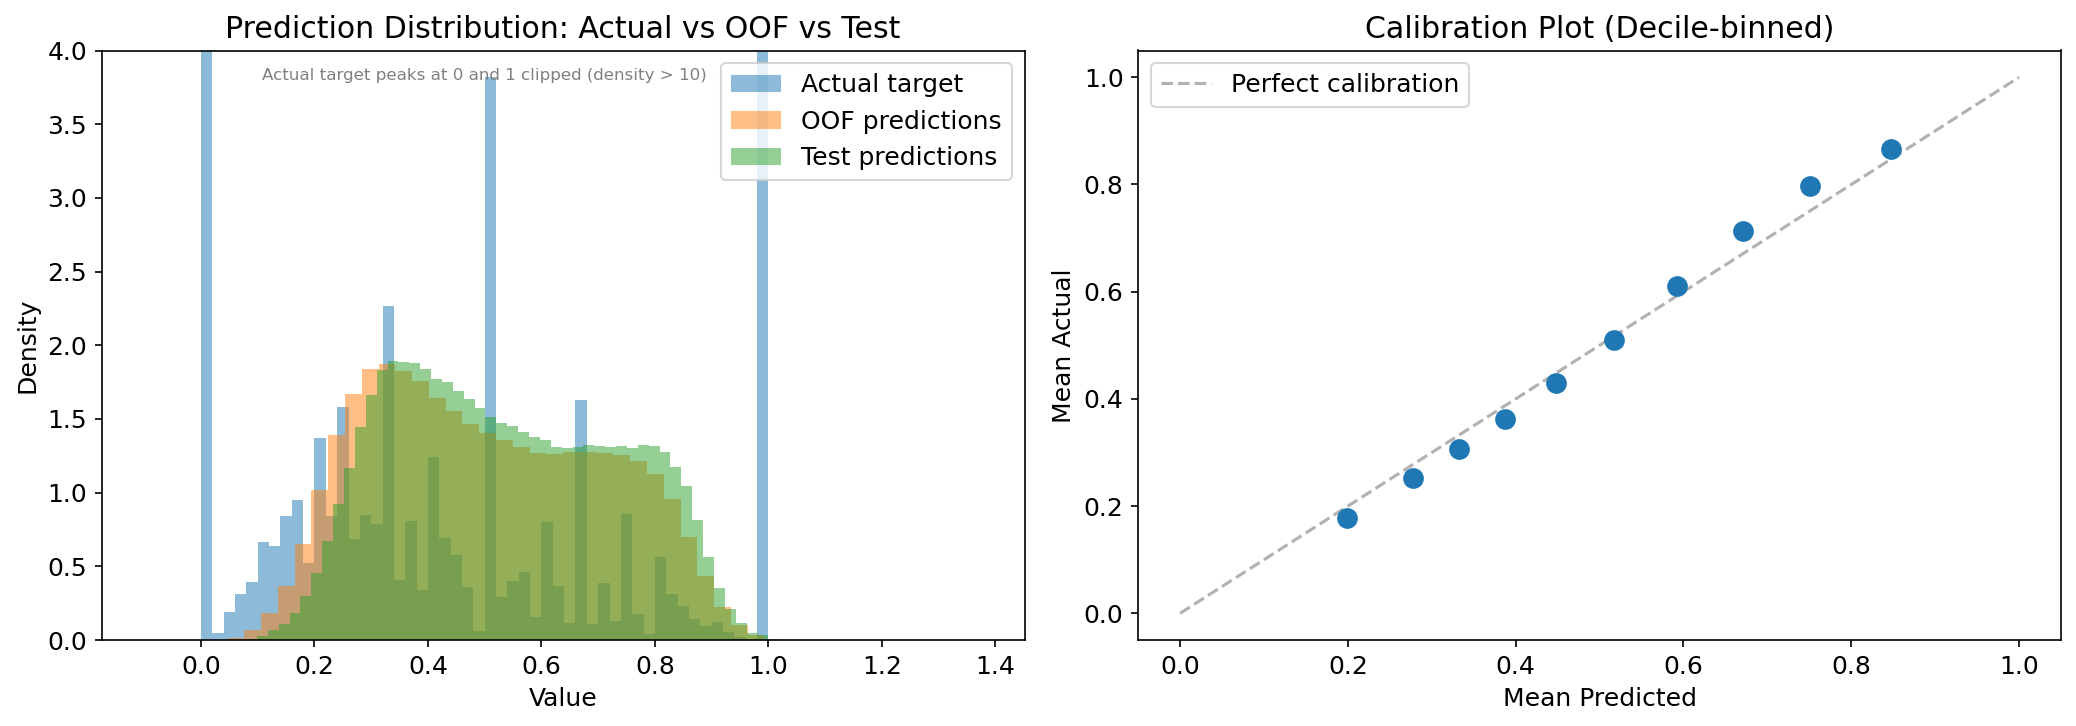

Saved: figures/prediction_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overlaid histograms — actual vs OOF vs test predictions
axes[0].hist(train_df[TARGET], bins=50, alpha=0.5, label='Actual target', density=True)
axes[0].hist(ens_oof, bins=50, alpha=0.5, label='OOF predictions', density=True)
axes[0].hist(ens_test, bins=50, alpha=0.5, label='Test predictions', density=True)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Prediction Distribution: Actual vs OOF vs Test')
axes[0].set_ylim(0, 4)
axes[0].legend()
axes[0].annotate('Actual target peaks at 0 and 1 clipped (density > 10)',
                 xy=(0.5, 3.8), fontsize=8, color='gray', ha='center')

# Right: Calibration curve (decile-binned)
deciles = pd.qcut(ens_oof, 10, duplicates='drop')
cal_df = pd.DataFrame({'pred': ens_oof, 'actual': train_df[TARGET].values, 'bin': deciles})
cal_grouped = cal_df.groupby('bin', observed=True).agg(
    pred_mean=('pred', 'mean'), actual_mean=('actual', 'mean')
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
axes[1].scatter(cal_grouped['pred_mean'], cal_grouped['actual_mean'], s=80, zorder=5)
axes[1].set_xlabel('Mean Predicted')
axes[1].set_ylabel('Mean Actual')
axes[1].set_title('Calibration Plot (Decile-binned)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/prediction_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/prediction_distribution.png')

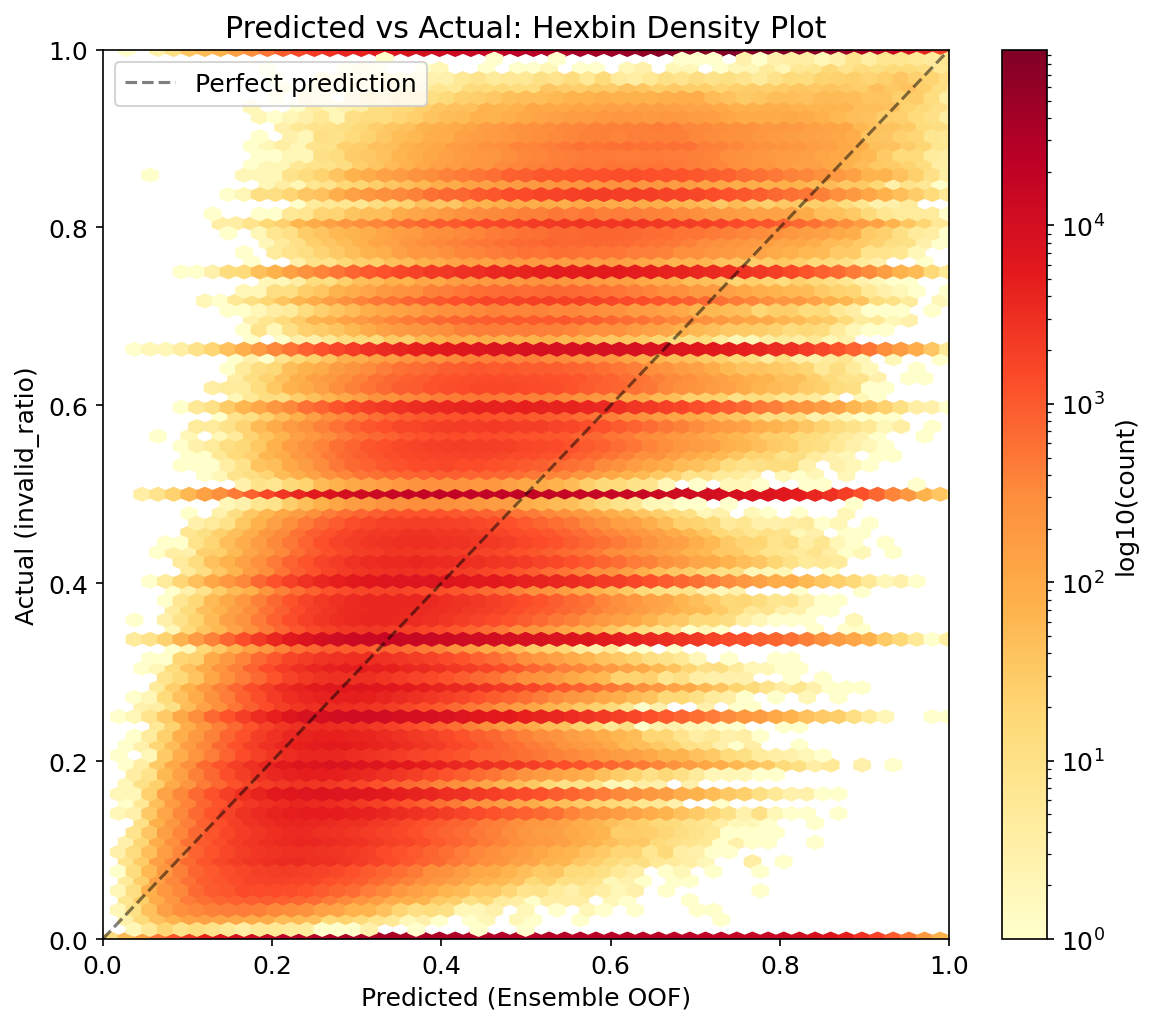

Saved: figures/pred_vs_actual.png


In [9]:
# Predicted vs Actual hexbin scatter plot
fig, ax = plt.subplots(figsize=(8, 7))

hb = ax.hexbin(ens_oof, train_df[TARGET].values, gridsize=80,
               cmap='YlOrRd', mincnt=1, bins='log')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Predicted (Ensemble OOF)')
ax.set_ylabel('Actual (invalid_ratio)')
ax.set_title('Predicted vs Actual: Hexbin Density Plot')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
cb = plt.colorbar(hb, ax=ax)
cb.set_label('log10(count)')

plt.tight_layout()
plt.savefig('../figures/pred_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/pred_vs_actual.png')


## Section 6: OOF-Platform Gap Analysis

Investigate why OOF Spearman (0.5880) is higher than platform score (0.5222). Key suspects: K-Fold TE leakage and distribution shift between train/test TE features.

In [10]:
# LGB vs XGB OOF correlation (measures model diversity — lower = more ensemble benefit)
lgb_xgb_corr, _ = spearmanr(lgb_oof, xgb_oof)
print(f'LGB-XGB OOF Spearman correlation: {lgb_xgb_corr:.4f}')
print(f'  -> {"High" if lgb_xgb_corr > 0.95 else "Moderate"} correlation — '
      f'{"limited" if lgb_xgb_corr > 0.95 else "some"} diversity for ensembling')

# OOF vs Platform gap summary
print(f'\n=== OOF vs Platform Gap ===')
print(f'  LightGBM  OOF: {lgb_oof_rho:.4f} -> Platform: 0.5182 (gap: {lgb_oof_rho - 0.5182:.4f})')
print(f'  Ensemble  OOF: {ens_oof_rho:.4f} -> Platform: 0.5222 (gap: {ens_oof_rho - 0.5222:.4f})')
print(f'\nPossible causes:')
print(f'  1. K-Fold TE leakage: 5-fold encoding has mild info leak within train')
print(f'  2. Distribution shift: test TE values may differ from train distribution')
print(f'  3. Data distribution: test set may have different spatial/temporal mix')

LGB-XGB OOF Spearman correlation: 0.9778
  -> High correlation — limited diversity for ensembling

=== OOF vs Platform Gap ===
  LightGBM  OOF: 0.5815 -> Platform: 0.5182 (gap: 0.0633)
  Ensemble  OOF: 0.5880 -> Platform: 0.5222 (gap: 0.0658)

Possible causes:
  1. K-Fold TE leakage: 5-fold encoding has mild info leak within train
  2. Distribution shift: test TE values may differ from train distribution
  3. Data distribution: test set may have different spatial/temporal mix


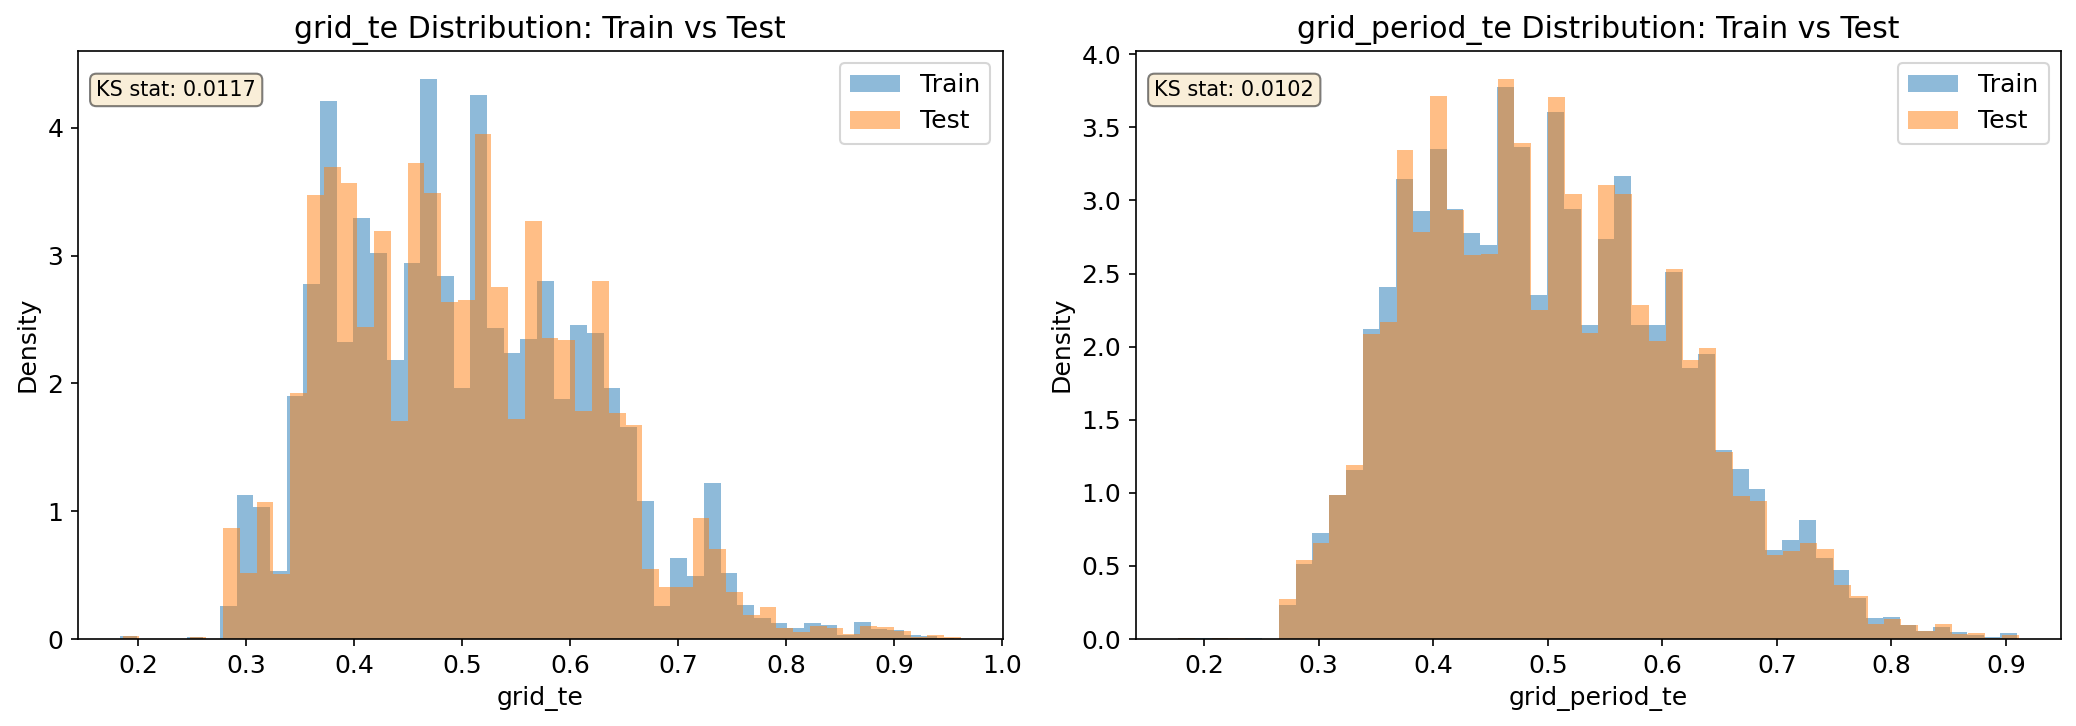

Saved: figures/te_distribution_shift.png


In [11]:
# Target Encoding distribution shift: Train vs Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(['grid_te', 'grid_period_te']):
    axes[i].hist(train_df[col], bins=50, alpha=0.5, label='Train', density=True)
    axes[i].hist(test_df[col], bins=50, alpha=0.5, label='Test', density=True)
    axes[i].set_title(f'{col} Distribution: Train vs Test')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

    # KS statistic for quantifying shift
    ks_stat, ks_p = ks_2samp(train_df[col].dropna(), test_df[col].dropna())
    axes[i].text(0.02, 0.95, f'KS stat: {ks_stat:.4f}', transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../figures/te_distribution_shift.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/te_distribution_shift.png')

## Section 7: SHAP Analysis

Use SHAP (TreeExplainer) on the LightGBM fold-0 model to explain feature contributions. Generate:
1. Summary plot (beeswarm) — for report
2. Bar plot — for video (simpler)
3. Dependence plots for top 3 features

In [12]:
import shap

# Load saved LightGBM fold-0 model
model = lgb.Booster(model_file='../models/lgbm_fold0.txt')

# Compute SHAP values on 10K sample
sample = train_df.sample(10000, random_state=SEED)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample[FEATURES])

print(f'SHAP values shape: {shap_values.shape}')
print(f'Sample shape: {sample[FEATURES].shape}')

/opt/anaconda3/envs/parking/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (10000, 26)
Sample shape: (10000, 26)


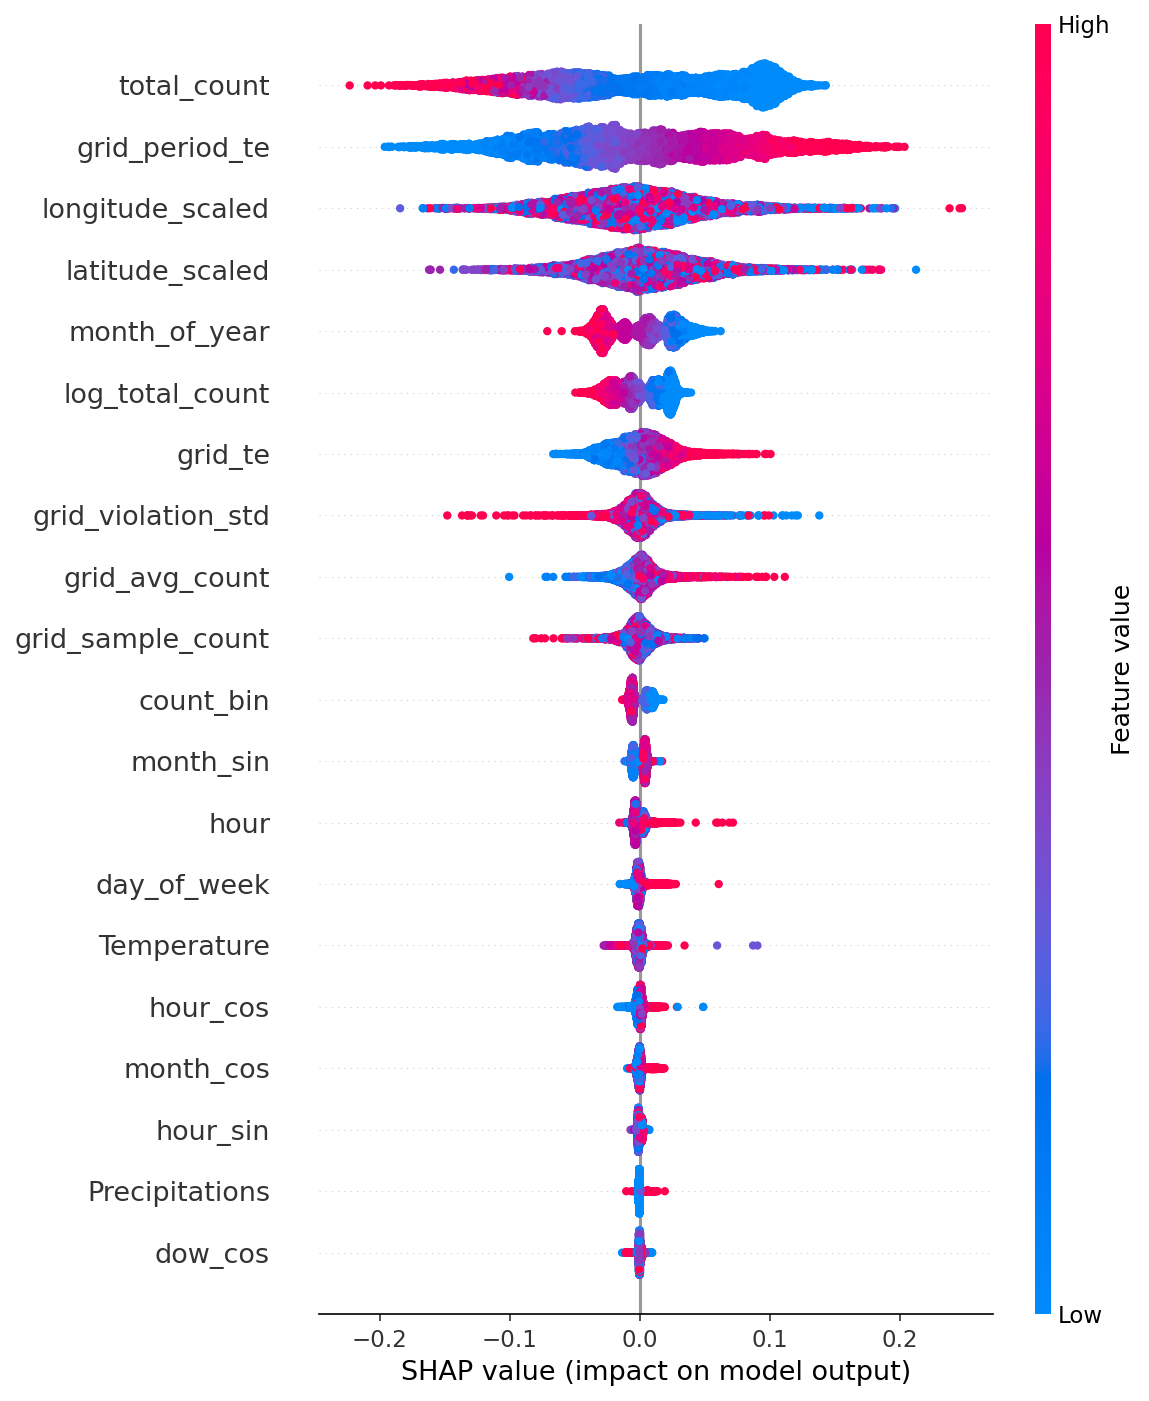

Saved: figures/shap_summary.png


In [13]:
# SHAP Summary Plot (beeswarm) — for report
shap.summary_plot(shap_values, sample[FEATURES], show=False)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/shap_summary.png')

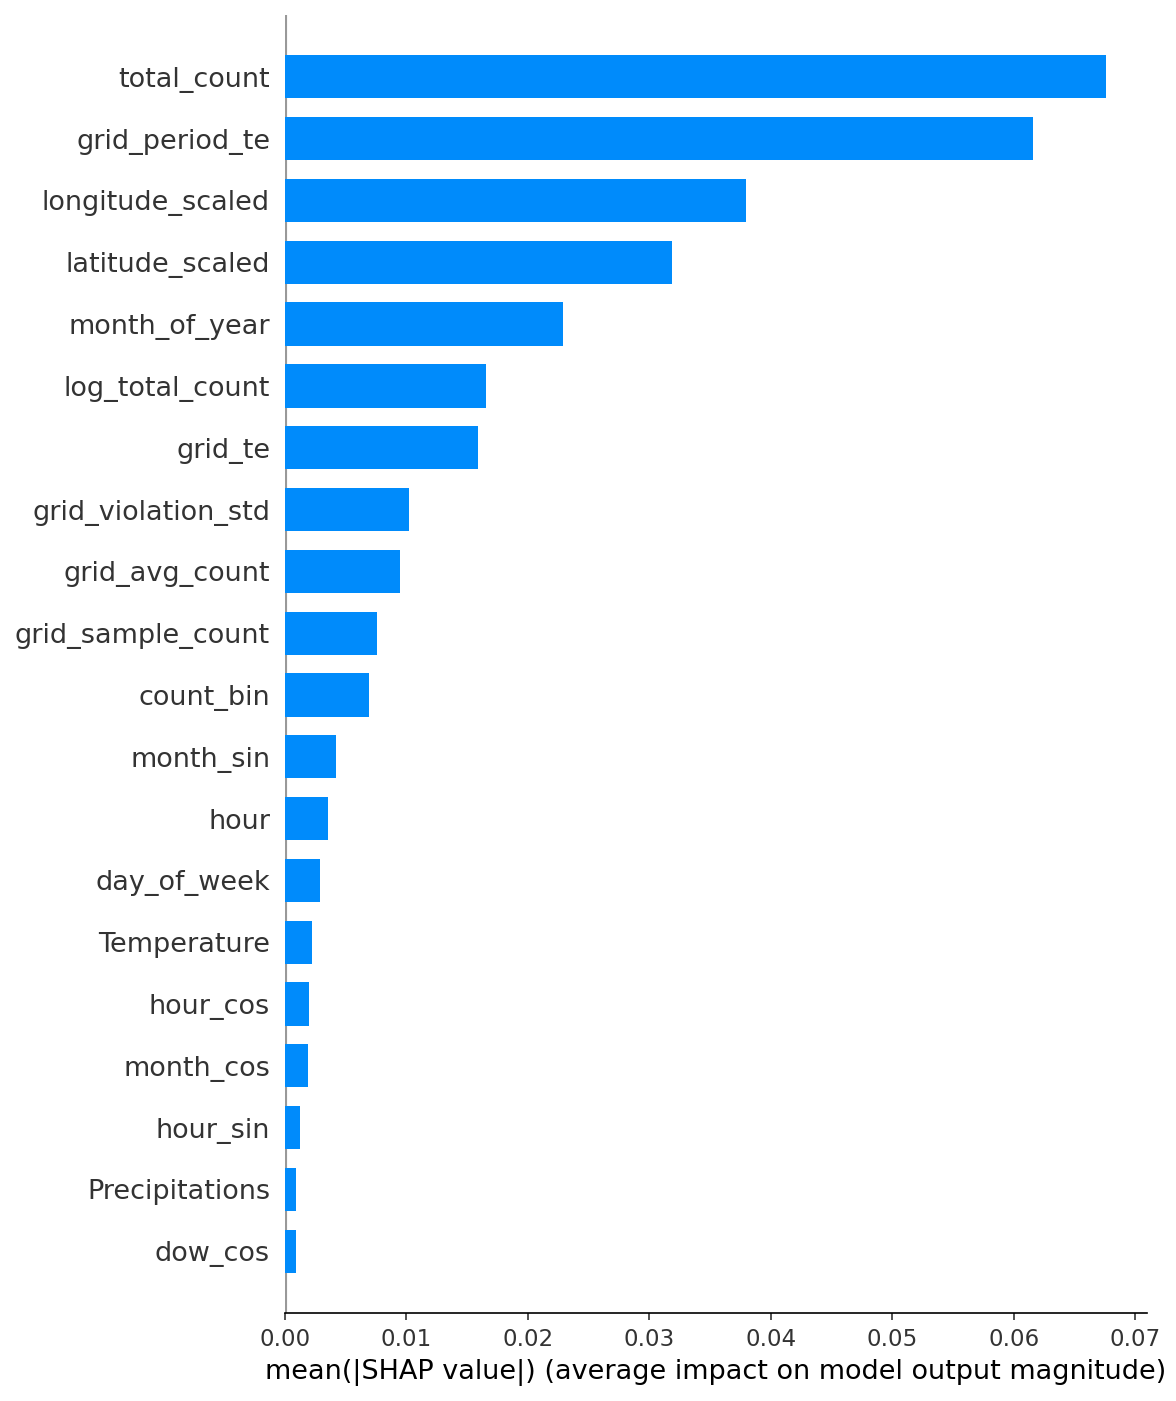

Saved: figures/shap_bar.png


In [ ]:
# SHAP Bar Plot — for video (cleaner, simpler)
shap.summary_plot(shap_values, sample[FEATURES], plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/shap_bar.png')

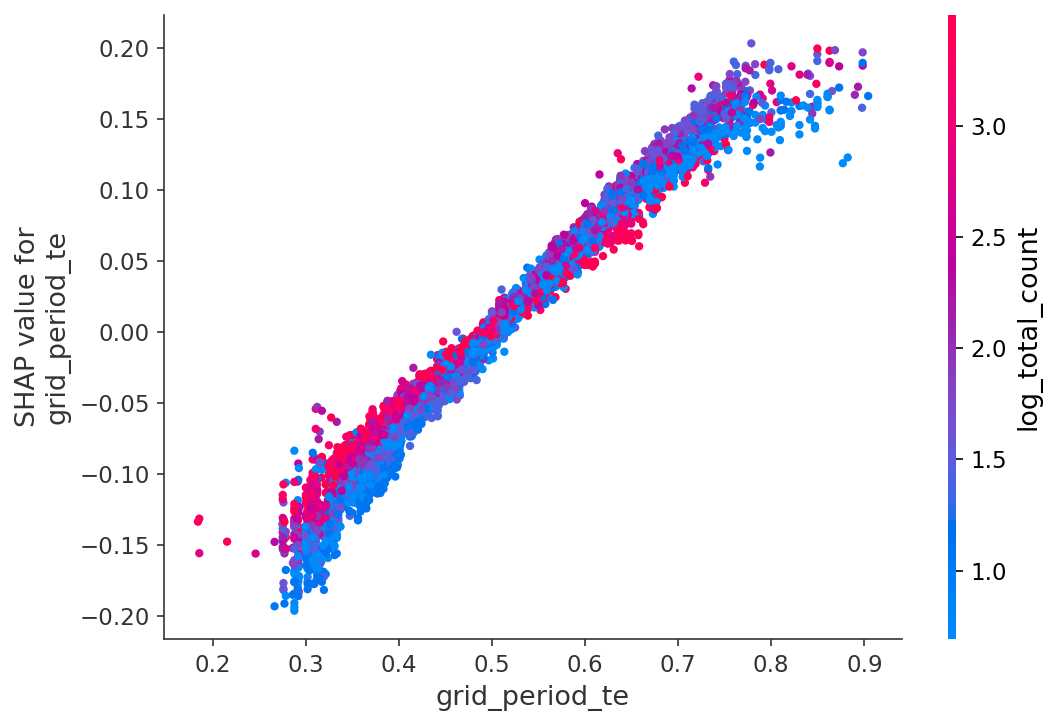

Saved: figures/shap_dep_grid_period_te.png


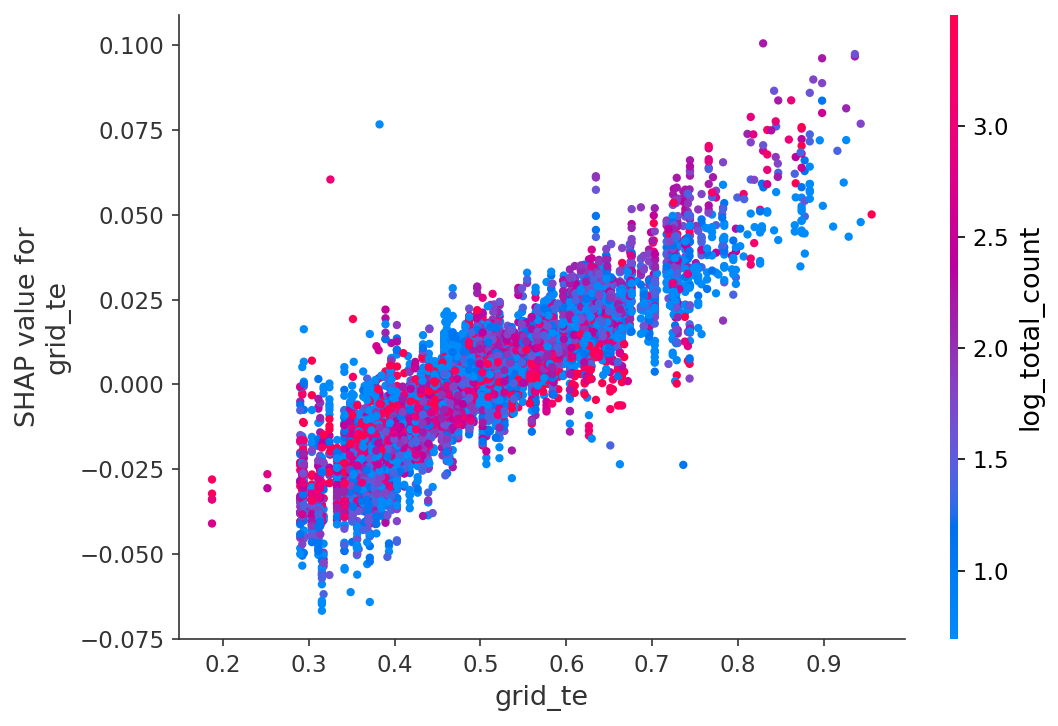

Saved: figures/shap_dep_grid_te.png


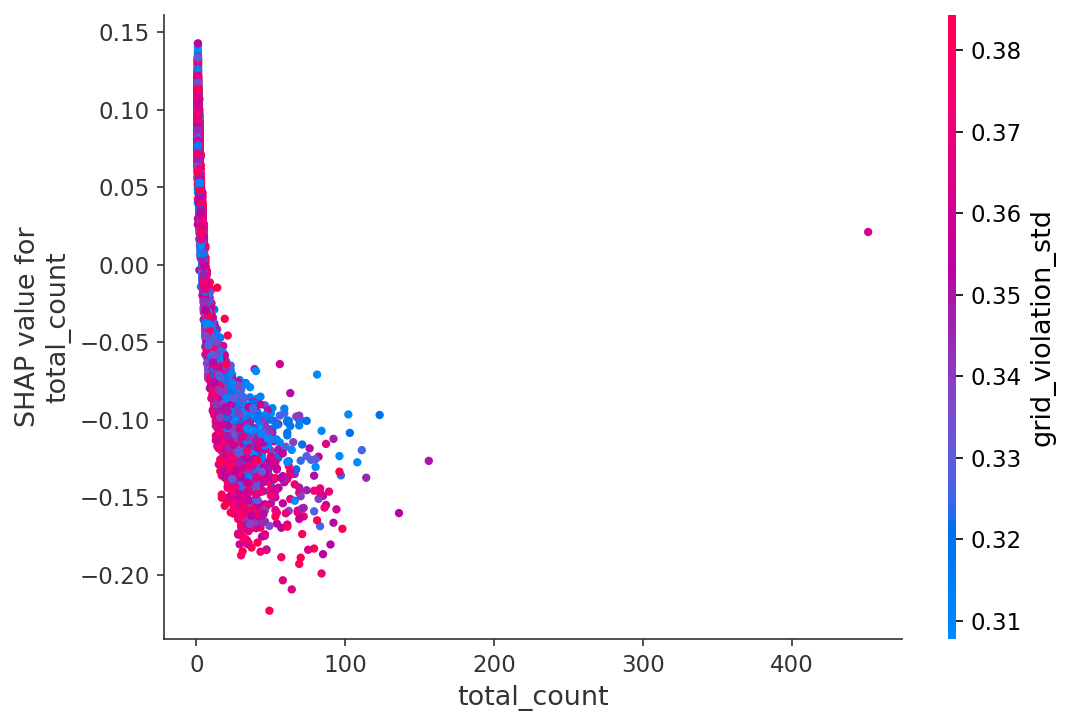

Saved: figures/shap_dep_total_count.png


In [14]:
# SHAP Dependence Plots for top 3 features
for feat in ['grid_period_te', 'grid_te', 'total_count']:
    shap.dependence_plot(feat, shap_values, sample[FEATURES], show=False)
    plt.tight_layout()
    plt.savefig(f'../figures/shap_dep_{feat}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/shap_dep_{feat}.png')

## Section 8: Results Summary

Compile all evaluation findings for report Chapter 5.

In [15]:
print('=' * 70)
print('PHASE 4 EVALUATION SUMMARY')
print('=' * 70)

print('\n--- Model Comparison ---')
print(results.to_string(index=False))

print('\n--- Ablation Study (if completed) ---')
if ablation_results:
    for name, rho in ablation_results.items():
        print(f'  {name}: {rho:.4f}')
else:
    print('  (Ablation study not yet run)')

print('\n--- Grouped Error Analysis ---')
for r in group_results:
    print(f'  count_bin={r["count_bin"]}: Spearman={r["spearman"]:.4f} (n={r["n"]:,})')
for r in threshold_results:
    print(f'  {r["subset"]}: Spearman={r["spearman"]:.4f} (n={r["n"]:,})')

print(f'\n--- Model Diversity ---')
print(f'  LGB-XGB OOF Spearman correlation: {lgb_xgb_corr:.4f}')

print(f'\n--- OOF vs Platform Gap ---')
print(f'  LightGBM: {lgb_oof_rho:.4f} -> 0.5182 (gap: {lgb_oof_rho - 0.5182:.4f})')
print(f'  Ensemble: {ens_oof_rho:.4f} -> 0.5222 (gap: {ens_oof_rho - 0.5222:.4f})')

print('\n--- Figures Generated ---')
figures = [
    'model_comparison.png', 'ablation_study.png',
    'shap_summary.png', 'shap_bar.png',
    'shap_dep_grid_period_te.png', 'shap_dep_grid_te.png', 'shap_dep_total_count.png',
    'prediction_distribution.png', 'grouped_spearman.png', 'te_distribution_shift.png'
]
import os
for f in figures:
    path = f'../figures/{f}'
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {f}')

print('\n' + '=' * 70)

PHASE 4 EVALUATION SUMMARY

--- Model Comparison ---
                       Model OOF Spearman Platform Score                     Note
      RF Baseline (official)            —          0.197  10 trees, orig features
             LightGBM 5-Fold       0.5815         0.5182 3000 rounds, 26 features
              XGBoost 5-Fold       0.5870              — 3000 rounds, 26 features
Ensemble (30% LGB + 70% XGB)       0.5880         0.5222     Grid-searched weight

--- Ablation Study (if completed) ---
  Baseline (10 orig): 0.5679
  + count transforms: 0.5712
  + periodic encoding: 0.5677
  + spatial TE: 0.5746
  + cross TE: 0.5771
  Full (26 features): 0.5815

--- Grouped Error Analysis ---
  count_bin=0: Spearman=0.4106 (n=1,532,442)
  count_bin=1: Spearman=0.5678 (n=1,150,241)
  count_bin=2: Spearman=0.6486 (n=1,751,905)
  count_bin=3: Spearman=0.6811 (n=1,343,611)
  count_bin=4: Spearman=0.7304 (n=298,347)
  total_count = 1: Spearman=0.4106 (n=1,532,442)
  total_count > 1: Spearman=0.658